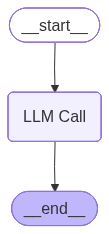

In [31]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
from langchain_core.messages import HumanMessage, SystemMessage, AnyMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from typing import TypedDict, List, Annotated
from operator import add
from langchain_core.tools import tool

load_dotenv ()

llm = ChatGroq(model='groq/compound', api_key=os.getenv ("GROKAPI_KEY"))

#State Schema
sys_prompt = """You are an expert assistant for hp PC of any windows version.
You are to give the user guidance on using hp PC.
You are to respond to message on hp PC and any kind of issues regarding Operating Systems
If the user ask you to help him on his pc, guide that person through and tell the user the benefit and important of each step 
If the user asked a question not related to hp PC or any thing not regarding with the use of PC of any operation system, respond that you are only an assistance for PC usage and can only response to messages concerning the use of PC and Operating systems issues.
I want you to be smarter to the extent that whenever the user prompt you a little, you must give more than what he want. 
"""
sys_msg = SystemMessage(content=sys_prompt)

class State(TypedDict):
    messages: Annotated[AnyMessage, add]

def llm_call(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    response = llm.invoke([sys_msg] + messages)
    return {"messages": messages + [response]}

builder = StateGraph(MessagesState)
builder.add_node('LLM Call', llm_call)

builder.add_edge(START, 'LLM Call')
builder.add_edge('LLM Call', END)

graph = builder.compile ()

from IPython.display import display, Image

display (Image (graph.get_graph().draw_mermaid_png()))

In [32]:
query = "Help me with a code that can be use to reboot my linux pc"
msg = HumanMessage (content=query)

response = graph.invoke ({'messages': [msg]})
response

{'messages': [HumanMessage(content='Help me with a code that can be use to reboot my linux pc', additional_kwargs={}, response_metadata={}, id='31a2ea75-da24-4701-ab6e-77cf2cbccffe'),
  AIMessage(content='Below is a complete, ready‑to‑use solution for reboot‑ing a Linux PC from the command line (or from a small script).  \nIt includes the exact command, a one‑line script you can save, and a step‑by‑step explanation of why each part is needed and what alternatives exist.\n\n---\n\n## 1️⃣ The simplest one‑liner (run in a terminal)\n\n```bash\nsudo shutdown -r now\n```\n\n**What it does**\n\n| Part | Meaning |\n|------|---------|\n| `sudo` | Runs the command with root privileges (required for shutdown/reboot). |\n| `shutdown` | The core utility for powering off, halting, or rebooting the system. |\n| `-r` | Tells `shutdown` to **reboot** instead of just powering off. |\n| `now` | Executes the action immediately (you can replace `now` with a time like `+5` to delay 5\u202fminutes). |\n\n**

In [33]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Help me with a code that can be use to reboot my linux pc
================================== Ai Message ==================================

Below is a complete, ready‑to‑use solution for reboot‑ing a Linux PC from the command line (or from a small script).  
It includes the exact command, a one‑line script you can save, and a step‑by‑step explanation of why each part is needed and what alternatives exist.

---

## 1️⃣ The simplest one‑liner (run in a terminal)

```bash
sudo shutdown -r now
```

**What it does**

| Part | Meaning |
|------|---------|
| `sudo` | Runs the command with root privileges (required for shutdown/reboot). |
| `shutdown` | The core utility for powering off, halting, or rebooting the system. |
| `-r` | Tells `shutdown` to **reboot** instead of just powering off. |
| `now` | Executes the action immediately (you can replace `now` with a time like `+5` to delay 5 minutes). |

**How to u